# Roulette Label Distribution Analysis

Analysis of manually labeled roulette videos across all 4 sets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## Load All 4 Sets

In [2]:
# Load all 4 datasets
dfs = {}
for set_num in [1, 2, 3, 4]:
    df = pd.read_csv(f'dataset_labels_manual_S{set_num}.csv')
    dfs[f'Set {set_num}'] = df
    print(f"Set {set_num}: {len(df)} videos")

# Combine all sets
combined = pd.concat(dfs.values(), ignore_index=True)
print(f"\nTotal videos: {len(combined)}")

Set 1: 438 videos
Set 2: 430 videos
Set 3: 326 videos
Set 4: 509 videos

Total videos: 1703


## Overall Label Statistics

In [3]:
# Count per label
label_counts = combined['label'].value_counts().sort_index()

print(f"Number of unique labels: {len(label_counts)}")
print(f"Min samples per class: {label_counts.min()}")
print(f"Max samples per class: {label_counts.max()}")
print(f"Mean samples per class: {label_counts.mean():.1f}")
print(f"Std samples per class: {label_counts.std():.1f}")

print(f"\nLabels with < 40 samples:")
print(label_counts[label_counts < 40])

Number of unique labels: 37
Min samples per class: 34
Max samples per class: 63
Mean samples per class: 46.0
Std samples per class: 7.5

Labels with < 40 samples:
label
1     37
12    34
13    35
19    39
20    34
24    38
30    39
32    35
Name: count, dtype: int64


## Visualize Overall Distribution

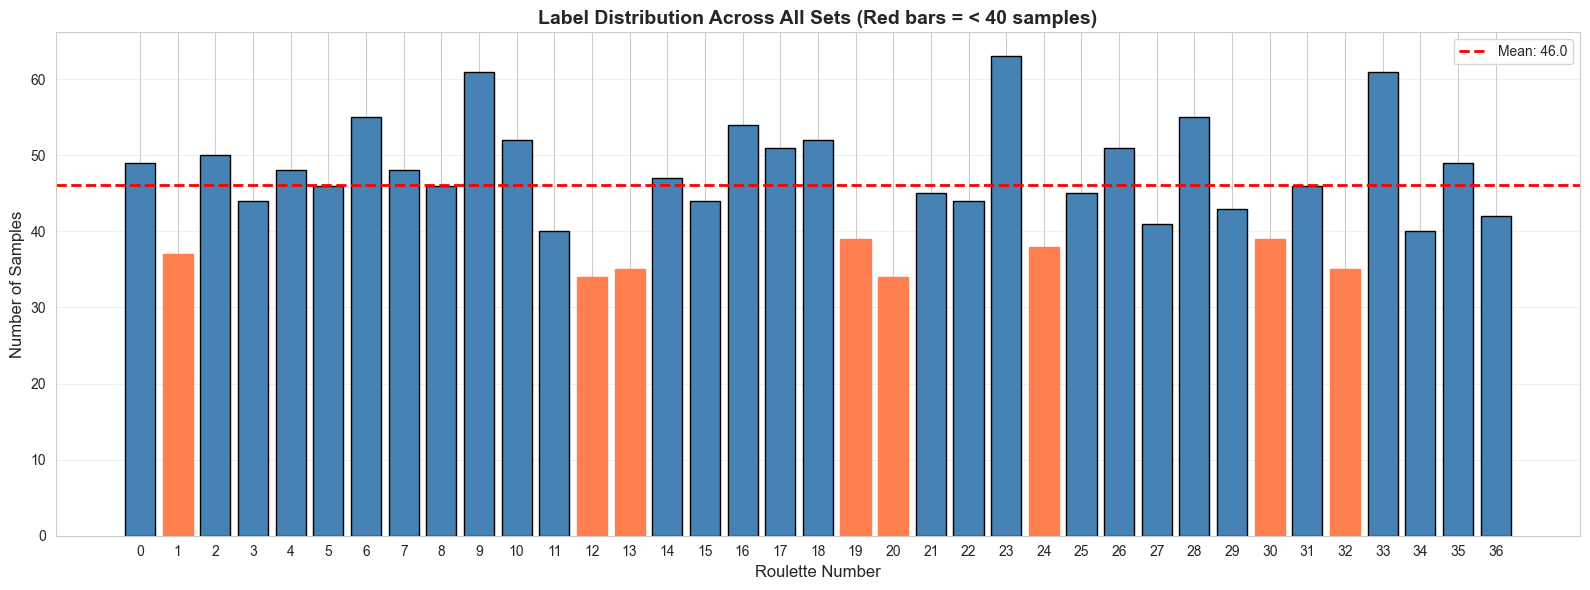

In [4]:
fig, ax = plt.subplots(figsize=(16, 6))

bars = ax.bar(label_counts.index, label_counts.values, color='steelblue', edgecolor='black')

# Highlight bars with low counts
for i, (label, count) in enumerate(label_counts.items()):
    if count < 40:
        bars[i].set_color('coral')

ax.axhline(label_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {label_counts.mean():.1f}')
ax.set_xlabel('Roulette Number', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Label Distribution Across All Sets (Red bars = < 40 samples)', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 37))
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Compare Distribution Across Sets

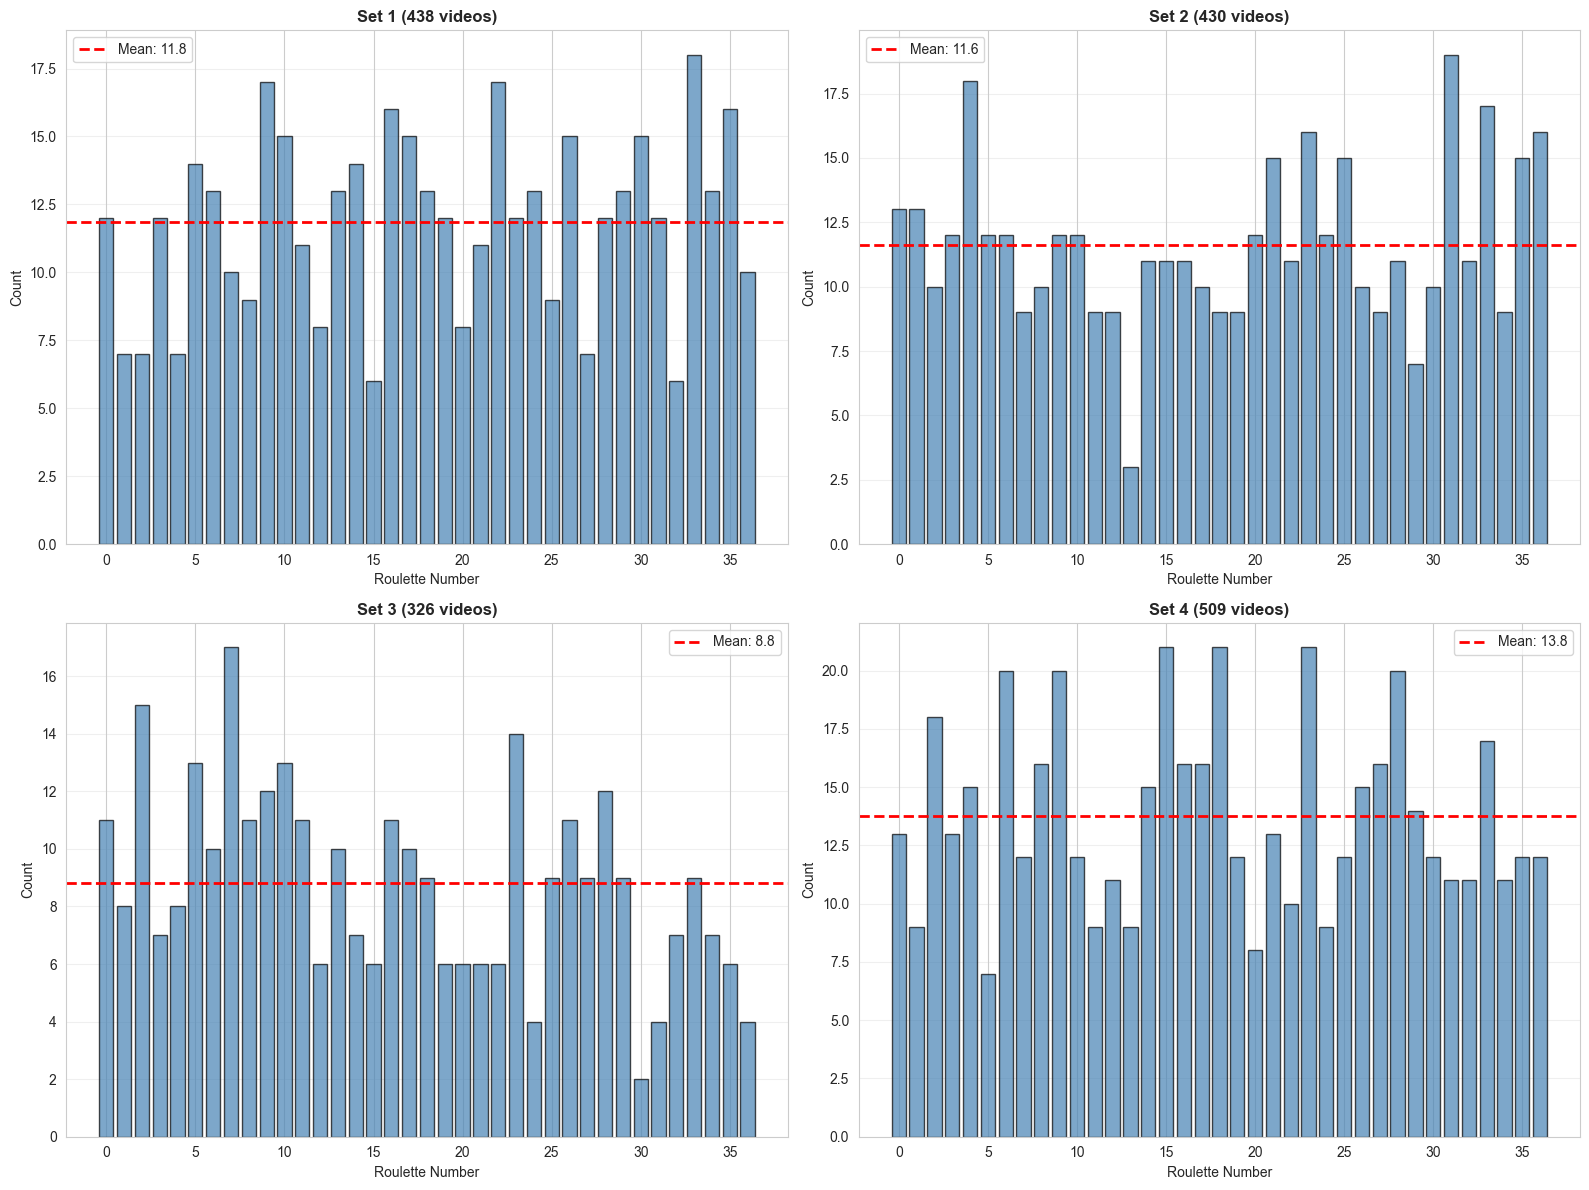

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (set_name, df) in enumerate(dfs.items()):
    counts = df['label'].value_counts().sort_index()
    
    axes[idx].bar(counts.index, counts.values, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].axhline(counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {counts.mean():.1f}')
    axes[idx].set_xlabel('Roulette Number', fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].set_title(f'{set_name} ({len(df)} videos)', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(range(0, 37, 5))
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Statistics by Set

In [6]:
summary = []
for set_name, df in dfs.items():
    counts = df['label'].value_counts()
    summary.append({
        'Set': set_name,
        'Total Videos': len(df),
        'Unique Labels': len(counts),
        'Min Count': counts.min(),
        'Max Count': counts.max(),
        'Mean Count': counts.mean(),
        'Std Count': counts.std()
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

  Set  Total Videos  Unique Labels  Min Count  Max Count  Mean Count  Std Count
Set 1           438             37          6         18   11.837838   3.329277
Set 2           430             37          3         19   11.621622   3.165362
Set 3           326             37          2         17    8.810811   3.340308
Set 4           509             37          7         21   13.756757   3.960958


## Save Combined Dataset

In [7]:
# Save combined dataset for training
combined.to_csv('dataset_labels_combined.csv', index=False)
print(f"✅ Saved {len(combined)} videos to dataset_labels_combined.csv")

✅ Saved 1703 videos to dataset_labels_combined.csv


## Frequency Baseline Check

Check if the model is just learning dataset distribution bias instead of real physics.

In [8]:
import pandas as pd
import numpy as np

# Load your combined labels
df = pd.read_csv('dataset_labels_combined.csv')

# Count frequency of each class
class_counts = df['label'].value_counts().sort_values(ascending=False)
print("Class frequency distribution:")
print(class_counts.head(10))

# Get top 5 most frequent classes
top5_frequent = class_counts.head(5).index.tolist()
print(f"\nTop 5 most frequent classes: {top5_frequent}")
print(f"Their counts: {class_counts.head(5).values}")

# Calculate "always predict top-5 frequent" baseline
total_samples = len(df)
top5_total = class_counts.head(5).sum()
frequency_baseline = (top5_total / total_samples) * 100

print(f"\n{'='*60}")
print(f"Frequency Baseline (always predict top-5 frequent):")
print(f"  Top-5 accuracy: {frequency_baseline:.2f}%")
print(f"  Your validation top-5: ~15%")
print(f"{'='*60}")

if frequency_baseline > 15:
    print("⚠️ WARNING: Your model is WORSE than frequency baseline!")
    print("   The model hasn't learned physics, just dataset bias.")
else:
    print("✅ GOOD: Model beats frequency baseline!")
    print(f"   Real improvement: {15 - frequency_baseline:.2f}% over frequency bias")

Class frequency distribution:
label
23    63
9     61
33    61
6     55
28    55
16    54
10    52
18    52
26    51
17    51
Name: count, dtype: int64

Top 5 most frequent classes: [23, 9, 33, 6, 28]
Their counts: [63 61 61 55 55]

Frequency Baseline (always predict top-5 frequent):
  Top-5 accuracy: 17.32%
  Your validation top-5: ~15%
⚠️ WARNING: Your model is WORSE than frequency baseline!
   The model hasn't learned physics, just dataset bias.


## Sample Size for Uniform Distribution

Calculate how many spins needed for approximately uniform distribution across all 37 classes.

In [9]:
from scipy import stats

# Current distribution
observed = df['label'].value_counts().sort_index().values
n_classes = 37
n_samples = len(df)

# Expected uniform distribution
expected_uniform = np.full(n_classes, n_samples / n_classes)

# Chi-square goodness of fit test
chi2_stat, p_value = stats.chisquare(observed, expected_uniform)

print(f"Current dataset size: {n_samples}")
print(f"Current samples per class: {n_samples / n_classes:.1f}")
print(f"\nChi-square test for uniformity:")
print(f"  Chi-square statistic: {chi2_stat:.2f}")
print(f"  P-value: {p_value:.6f}")

if p_value < 0.05:
    print(f"  ❌ Distribution is significantly NON-uniform (p < 0.05)")
else:
    print(f"  ✅ Distribution is approximately uniform (p >= 0.05)")

# Estimate samples needed for approximate uniformity
# Rule of thumb: need ~30-50 samples per class for stable distribution
samples_per_class_targets = [30, 50, 100, 200]

print(f"\n{'='*60}")
print("Estimated total samples needed for uniform distribution:")
print(f"{'='*60}")
for target in samples_per_class_targets:
    total_needed = target * n_classes
    additional_needed = max(0, total_needed - n_samples)
    print(f"  {target} per class: {total_needed:,} total ({additional_needed:+,} more needed)")

# Calculate coefficient of variation (lower = more uniform)
cv = (np.std(observed) / np.mean(observed)) * 100
print(f"\nCoefficient of variation: {cv:.2f}%")
print(f"  (0% = perfect uniform, higher = more skewed)")
print(f"  For fair roulette: expect CV around 10-15%")

Current dataset size: 1703
Current samples per class: 46.0

Chi-square test for uniformity:
  Chi-square statistic: 44.30
  P-value: 0.161348
  ✅ Distribution is approximately uniform (p >= 0.05)

Estimated total samples needed for uniform distribution:
  30 per class: 1,110 total (+0 more needed)
  50 per class: 1,850 total (+147 more needed)
  100 per class: 3,700 total (+1,997 more needed)
  200 per class: 7,400 total (+5,697 more needed)

Coefficient of variation: 16.13%
  (0% = perfect uniform, higher = more skewed)
  For fair roulette: expect CV around 10-15%
